# Tier 2 Heavyweight Verification Model
**Hurricane Flood-Damage Classification — Deep Full-Network Fine-Tuning**

This notebook develops a standalone, heavyweight verification model that complements the
lightweight frozen-backbone classifier in `project.ipynb`. It is deliberately slower and
more resource-intensive to produce refined, high-confidence verdicts.

### Key upgrades over the Tier 1 classifier
| Capability | Tier 1 | Tier 2 (this notebook) |
|---|---|---|
| Backbone | ResNet-50 (frozen) | EfficientNet-V2-M (full fine-tune) |
| Input resolution | 224 px | 480 px |
| Fine-tuning | Head only | Staged progressive unfreezing |
| Augmentation | Basic | RandAugment + Mixup |
| LR schedule | ReduceLROnPlateau | Cosine Annealing Warm Restarts |
| Training precision | FP32 | Mixed precision (AMP) |
| Memory | Standard | Gradient checkpointing |
| Inference | Single-pass | Test-Time Augmentation (TTA) |
| Calibration | None | Temperature scaling |
| Explainability | None | GradCAM heatmaps |
| Output | Class label | Label + severity + response action |

**Data source:** Satellite Images of Hurricane Damage — Quoc Dung Cao, Youngjun Choe (Kaggle)

## 1. Imports and environment setup

In [1]:
import os
import sys
import copy
import json
import random
import warnings
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from PIL import Image

# ── PyTorch ──────────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, WeightedRandomSampler
from torch.cuda.amp import GradScaler, autocast

try:
    from torchvision import datasets, transforms, models
    import torchvision.transforms.functional as TF
except ModuleNotFoundError:
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "torchvision"])
    from torchvision import datasets, transforms, models
    import torchvision.transforms.functional as TF

try:
    from tqdm.notebook import tqdm
except ModuleNotFoundError:
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "tqdm"])
    from tqdm.notebook import tqdm

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    precision_recall_curve,
    roc_auc_score,
    auc,
)

warnings.filterwarnings("ignore", category=UserWarning)

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ── Device ────────────────────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pin_memory = device.type == "cuda"
if device.type == "cuda":
    torch.backends.cudnn.benchmark = True
    print("GPU:", torch.cuda.get_device_name(0))

print("Python:", sys.executable)
print("PyTorch:", torch.__version__)
print("Device:", device)

USE_AMP = device.type == "cuda"   # Mixed precision requires CUDA
print("Mixed precision AMP:", USE_AMP)

GPU: NVIDIA H100 80GB HBM3 MIG 1g.10gb
Python: /opt/conda/bin/python
PyTorch: 2.10.0+cu128
Device: cuda
Mixed precision AMP: True


## 2. Data paths and inspection

In [2]:
ROOT       = Path("data")
TRAIN_DIR  = ROOT / "train_another"
VAL_DIR    = ROOT / "validation_another"
TEST_DIR   = ROOT / "test_another"
TEST2_DIR  = ROOT / "test"           # held-out second test set

for split in [TRAIN_DIR, VAL_DIR, TEST_DIR, TEST2_DIR]:
    print(f"\n{split}:")
    if split.exists():
        for cls_dir in sorted(split.iterdir()):
            if cls_dir.is_dir():
                count = len(list(cls_dir.glob("*.*")))
                print(f"  {cls_dir.name:20s} {count:>5d} images")
    else:
        print("  *** MISSING ***")


data/train_another:
  damage                5000 images
  no_damage             5000 images

data/validation_another:
  damage                1000 images
  no_damage             1000 images

data/test_another:
  damage                8000 images
  no_damage             1000 images

data/test:
  damage                1000 images
  no_damage             1000 images


## 3. Hyperparameters

In [3]:
# ── Resolution ────────────────────────────────────────────────────────────────
IMAGE_SIZE    = 480     # EfficientNet-V2-M native resolution
RESIZE_TO     = 560     # resize before centre-crop at eval time

# ── Data loading ──────────────────────────────────────────────────────────────
BATCH_SIZE    = 12      # lower than Tier 1 due to larger images; increase if VRAM allows
NUM_WORKERS   = min(4, os.cpu_count() or 1)

# ── Training phases ───────────────────────────────────────────────────────────
# Phase 1: train head only (fast warm-up)
PHASE1_EPOCHS = 3
PHASE1_LR     = 3e-4

# Phase 2: unfreeze top blocks
PHASE2_EPOCHS = 5
PHASE2_LR     = 5e-5

# Phase 3: full fine-tune with differential LRs
PHASE3_EPOCHS = 8
PHASE3_LR_HEAD    = 1e-4
PHASE3_LR_MID     = 2e-5
PHASE3_LR_STEM    = 5e-6

# ── Regularisation ────────────────────────────────────────────────────────────
WEIGHT_DECAY      = 1e-4
LABEL_SMOOTHING   = 0.05
FOCAL_GAMMA       = 2.0   # 0 → standard cross-entropy; >0 → focal loss
DROPOUT_HEAD      = 0.40
CLIP_GRAD_NORM    = 1.0

# ── Augmentation ──────────────────────────────────────────────────────────────
RANDAUG_N         = 2     # RandAugment: number of transforms applied per image
RANDAUG_M         = 9     # RandAugment: magnitude (0-30)
MIXUP_ALPHA       = 0.3   # Beta distribution parameter; 0 disables Mixup

# ── TTA ───────────────────────────────────────────────────────────────────────
TTA_AUGMENTATIONS = 5     # Number of augmented views at test time

print("Hyperparameters loaded.")
print(f"  Image size    : {IMAGE_SIZE}px")
print(f"  Batch size    : {BATCH_SIZE}")
print(f"  Total epochs  : {PHASE1_EPOCHS + PHASE2_EPOCHS + PHASE3_EPOCHS}")

Hyperparameters loaded.
  Image size    : 480px
  Batch size    : 12
  Total epochs  : 16


## 4. Data transforms and loaders

`RandAugment` applies a randomly sampled chain of photometric and geometric transforms,
giving the model broader exposure to imaging artefacts common in satellite imagery
(sensor noise, haze, radiometric variations).

In [4]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.65, 1.00), ratio=(0.9, 1.1)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(degrees=20),
    transforms.RandAugment(num_ops=RANDAUG_N, magnitude=RANDAUG_M),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize(RESIZE_TO),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# TTA uses light random augmentation at inference
tta_transform = transforms.Compose([
    transforms.Resize(RESIZE_TO),
    transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.85, 1.00)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# ── Datasets ──────────────────────────────────────────────────────────────────
train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
val_dataset   = datasets.ImageFolder(VAL_DIR,   transform=eval_transform)
test_dataset  = datasets.ImageFolder(TEST_DIR,  transform=eval_transform)

# TTA copies share same underlying files; only transform differs
test_tta_dataset = datasets.ImageFolder(TEST_DIR, transform=tta_transform)

# ── Class-balanced sampler ────────────────────────────────────────────────────
# WeightedRandomSampler ensures each batch mirrors the desired class ratio
class_counts   = np.bincount([lbl for _, lbl in train_dataset.samples])
sample_weights = [1.0 / class_counts[lbl] for _, lbl in train_dataset.samples]
sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(train_dataset),
    replacement=True,
)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE,
    sampler=sampler,           # replaces shuffle=True
    num_workers=NUM_WORKERS, pin_memory=pin_memory,
    persistent_workers=NUM_WORKERS > 0,
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=pin_memory,
    persistent_workers=NUM_WORKERS > 0,
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=pin_memory,
    persistent_workers=NUM_WORKERS > 0,
)
test_tta_loader = DataLoader(
    test_tta_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=pin_memory,
    persistent_workers=NUM_WORKERS > 0,
)

CLASSES = train_dataset.classes
DAMAGE_IDX = CLASSES.index("damage") if "damage" in CLASSES else 1

print("Classes      :", CLASSES, f"  (damage idx={DAMAGE_IDX})")
print("Train  size  :", len(train_dataset))
print("Val    size  :", len(val_dataset))
print("Test   size  :", len(test_dataset))
print("Class counts :", dict(zip(CLASSES, class_counts)))

Classes      : ['damage', 'no_damage']   (damage idx=0)
Train  size  : 10000
Val    size  : 2000
Test   size  : 9000
Class counts : {'damage': np.int64(5000), 'no_damage': np.int64(5000)}


## 5. Visualise sample images

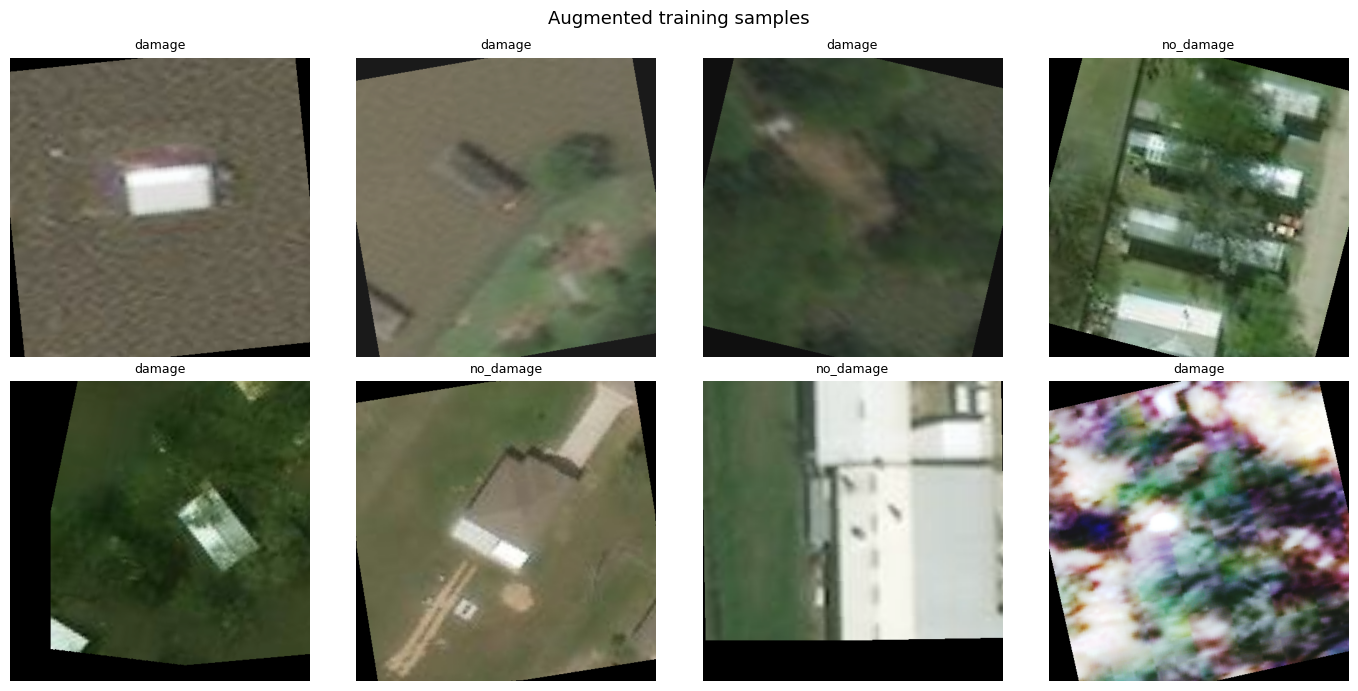

In [5]:
def show_batch(loader, classes, nrows=2, ncols=4, title="Sample batch"):
    """Denormalise and display a grid of images from a DataLoader."""
    images, labels = next(iter(loader))
    images = images[: nrows * ncols].cpu()
    labels = labels[: nrows * ncols].cpu()
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std  = torch.tensor(IMAGENET_STD).view(3, 1, 1)

    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.5, nrows * 3.5))
    fig.suptitle(title, fontsize=13)
    for idx, ax in enumerate(axes.flatten()):
        img = (images[idx] * std + mean).permute(1, 2, 0).numpy().clip(0, 1)
        ax.imshow(img)
        ax.set_title(classes[labels[idx]], fontsize=9)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

show_batch(train_loader, CLASSES, title="Augmented training samples")

## 6. Focal Loss

Focal Loss down-weights well-classified easy examples and focuses training on hard
negatives — particularly useful for satellite images where undamaged areas vastly
outnumber flood-damaged regions in real deployments.

In [6]:
class FocalLoss(nn.Module):
    """
    Multi-class focal loss with optional class weights and label smoothing.

    FL(p_t) = -alpha_t * (1 - p_t)^gamma * log(p_t)

    When gamma=0 this reduces to weighted cross-entropy with label smoothing.
    """

    def __init__(self, gamma: float = 2.0, weight=None, label_smoothing: float = 0.0):
        super().__init__()
        self.gamma           = gamma
        self.label_smoothing = label_smoothing
        self.register_buffer("weight", weight)

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        num_classes = logits.size(1)

        # Smooth labels: (1 - ε) on the true class, ε / C elsewhere
        with torch.no_grad():
            smooth_targets = torch.full_like(logits, self.label_smoothing / num_classes)
            smooth_targets.scatter_(1, targets.unsqueeze(1), 1.0 - self.label_smoothing + self.label_smoothing / num_classes)

        log_probs = F.log_softmax(logits, dim=1)
        probs     = log_probs.exp()

        # Per-sample focal weight: (1 - p_true)^gamma
        p_t = (probs * smooth_targets).sum(dim=1)  # shape [B]
        focal_weight = (1 - p_t) ** self.gamma      # shape [B]

        # Cross-entropy over smooth targets
        ce = -(smooth_targets * log_probs).sum(dim=1)  # shape [B]

        if self.weight is not None:
            class_w = self.weight[targets]             # shape [B]
            ce = ce * class_w

        loss = (focal_weight * ce).mean()
        return loss


# Class weights to handle remaining imbalance
class_weights = torch.tensor(
    [len(train_dataset) / (len(CLASSES) * c) for c in class_counts],
    dtype=torch.float32,
).to(device)
print("Class weights:", class_weights)

criterion = FocalLoss(
    gamma=FOCAL_GAMMA,
    weight=class_weights,
    label_smoothing=LABEL_SMOOTHING,
).to(device)

Class weights: tensor([1., 1.], device='cuda:0')


## 7. Model — EfficientNet-V2-M with a richer classification head

**EfficientNet-V2-M** offers a better accuracy/FLOP trade-off than ResNet-50 and the
smaller V2-S, while still being trainable on a laptop GPU in reasonable time.
Gradient checkpointing halves activation memory at the cost of a small re-compute.

In [7]:
def build_model(num_classes: int = 2) -> nn.Module:
    """Build EfficientNet-V2-M with a richer, dropout-regularised head."""
    backbone = models.efficientnet_v2_m(
        weights=models.EfficientNet_V2_M_Weights.IMAGENET1K_V1
    )

    # Enable gradient checkpointing on all feature blocks to save activation memory
    for block in backbone.features:
        if hasattr(block, "gradient_checkpointing"):
            block.gradient_checkpointing = True

    in_features = backbone.classifier[1].in_features

    # Multi-layer head: Linear → BN → Activation → Dropout → Linear
    backbone.classifier = nn.Sequential(
        nn.Dropout(p=DROPOUT_HEAD),
        nn.Linear(in_features, 512),
        nn.BatchNorm1d(512),
        nn.SiLU(),
        nn.Dropout(p=0.20),
        nn.Linear(512, 128),
        nn.SiLU(),
        nn.Linear(128, num_classes),
    )
    return backbone


def freeze_backbone(model: nn.Module):
    """Freeze all feature-extraction layers; head remains trainable."""
    for param in model.features.parameters():
        param.requires_grad = False


def unfreeze_top_blocks(model: nn.Module, num_blocks: int = 4):
    """Unfreeze the last N feature blocks (EfficientNet-V2-M has 8)."""
    blocks = list(model.features.children())
    for block in blocks[-num_blocks:]:
        for param in block.parameters():
            param.requires_grad = True


def unfreeze_all(model: nn.Module):
    """Enable gradients for every parameter."""
    for param in model.parameters():
        param.requires_grad = True


model = build_model(num_classes=len(CLASSES)).to(device)

total  = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters     : {total:,}")
print(f"Trainable parameters : {trainable:,}")

Total parameters     : 53,581,174
Trainable parameters : 53,581,174


## 8. Mixup augmentation helper

Mixup linearly interpolates pairs of training examples and their labels, creating
virtual examples that sit between real data manifolds. Combined with RandAugment it
significantly regularises deep feature representations.

In [8]:
def mixup_batch(
    images: torch.Tensor,
    targets: torch.Tensor,
    alpha: float = MIXUP_ALPHA,
    num_classes: int = 2,
):
    """
    Apply Mixup to a batch.

    Returns mixed images and soft (one-hot) target tensors.
    Disable by setting alpha=0 — returns hard one-hot targets.
    """
    if alpha <= 0:
        return images, F.one_hot(targets, num_classes).float()

    lam   = np.random.beta(alpha, alpha)
    idx   = torch.randperm(images.size(0), device=images.device)
    mixed = lam * images + (1 - lam) * images[idx]

    y_a   = F.one_hot(targets,      num_classes).float()
    y_b   = F.one_hot(targets[idx], num_classes).float()
    mixed_targets = lam * y_a + (1 - lam) * y_b

    return mixed, mixed_targets


def focal_loss_soft(logits: torch.Tensor, soft_targets: torch.Tensor,
                    gamma: float = FOCAL_GAMMA) -> torch.Tensor:
    """
    Focal loss with soft (Mixup) targets.
    Falls back to criterion when Mixup is disabled.
    """
    log_probs = F.log_softmax(logits, dim=1)
    probs     = log_probs.exp()
    p_t       = (probs * soft_targets).sum(dim=1)
    focal_w   = (1 - p_t) ** gamma
    ce        = -(soft_targets * log_probs).sum(dim=1)
    return (focal_w * ce).mean()


print("Mixup helpers defined.")

Mixup helpers defined.


## 9. Training and evaluation functions

In [9]:
def train_one_epoch(
    model, loader, optimizer, scaler,
    epoch_idx: int, total_epochs: int,
    use_mixup: bool = True,
) -> tuple[float, float]:
    """Train for one epoch. Returns (loss, accuracy)."""
    model.train()
    running_loss = 0.0
    running_correct = 0
    n_samples = 0

    for inputs, labels in tqdm(loader, desc=f"Epoch {epoch_idx}/{total_epochs} [train]", leave=False):
        inputs = inputs.to(device, non_blocking=pin_memory)
        labels = labels.to(device, non_blocking=pin_memory)

        # Mixup in pixel space
        if use_mixup and MIXUP_ALPHA > 0:
            inputs, soft_labels = mixup_batch(inputs, labels, alpha=MIXUP_ALPHA)
        else:
            soft_labels = None

        optimizer.zero_grad(set_to_none=True)

        with autocast(enabled=USE_AMP):
            logits = model(inputs)
            if soft_labels is not None:
                loss = focal_loss_soft(logits, soft_labels, gamma=FOCAL_GAMMA)
            else:
                loss = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), CLIP_GRAD_NORM)
        scaler.step(optimizer)
        scaler.update()

        bs = inputs.size(0)
        running_loss    += loss.item() * bs
        running_correct += (logits.argmax(1) == labels).sum().item()
        n_samples       += bs

    return running_loss / n_samples, running_correct / n_samples


@torch.no_grad()
def evaluate(
    model, loader,
) -> tuple[float, float, np.ndarray, np.ndarray, np.ndarray]:
    """
    Evaluate on a DataLoader.

    Returns: (loss, accuracy, labels, probs, logits)
    """
    model.eval()
    running_loss = 0.0
    all_labels, all_logits = [], []

    for inputs, labels in loader:
        inputs = inputs.to(device, non_blocking=pin_memory)
        labels = labels.to(device, non_blocking=pin_memory)
        with autocast(enabled=USE_AMP):
            logits = model(inputs)
            loss   = criterion(logits, labels)
        running_loss += loss.item() * inputs.size(0)
        all_labels.append(labels.cpu())
        all_logits.append(logits.cpu().float())

    all_labels = torch.cat(all_labels).numpy()
    all_logits = torch.cat(all_logits)          # float tensor on CPU
    all_probs  = torch.softmax(all_logits, dim=1)[:, DAMAGE_IDX].numpy()
    epoch_loss = running_loss / len(loader.dataset)
    preds = (all_probs < 0.5).astype(int)  # low damage prob → no_damage (label 1)
    epoch_acc = (preds == all_labels).mean()
    return epoch_loss, epoch_acc, all_labels, all_probs, all_logits.numpy()


print("Training helpers defined.")

Training helpers defined.


## 10. Staged progressive training

Three phases with progressively lower learning rates avoid catastrophic forgetting
of ImageNet features:

1. **Phase 1** — head only, high LR, fast convergence
2. **Phase 2** — top 4 backbone blocks + head, medium LR
3. **Phase 3** — full network with differential LRs (stem < mid < head)

In [10]:
history = {
    "train_loss": [], "train_acc": [],
    "val_loss":   [], "val_acc":   [], "val_f1": [],
    "lr": [],
}
best_val_f1   = 0.0
best_weights  = copy.deepcopy(model.state_dict())
scaler        = GradScaler(enabled=USE_AMP)


def run_phase(
    phase_name: str,
    epochs: int,
    optimizer,
    scheduler,
    use_mixup: bool = True,
):
    global best_val_f1, best_weights
    total_so_far = len(history["train_loss"]) + 1

    for e in range(epochs):
        epoch_idx = total_so_far + e
        total_epochs_disp = total_so_far + epochs - 1

        train_loss, train_acc = train_one_epoch(
            model, train_loader, optimizer, scaler,
            epoch_idx, total_epochs_disp, use_mixup=use_mixup,
        )
        val_loss, val_acc, val_labels, val_probs, _ = evaluate(model, val_loader)
        val_preds = (val_probs < 0.5).astype(int)
        val_f1    = f1_score(val_labels, val_preds, zero_division=0)

        if scheduler is not None:
            if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(val_f1)
            else:
                scheduler.step()

        current_lr = optimizer.param_groups[0]["lr"]
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["val_f1"].append(val_f1)
        history["lr"].append(current_lr)

        if val_f1 > best_val_f1:
            best_val_f1  = val_f1
            best_weights = copy.deepcopy(model.state_dict())

        print(
            f"[{phase_name}] ep {epoch_idx:02d} | "
            f"train_loss={train_loss:.4f}  train_acc={train_acc:.4f} | "
            f"val_loss={val_loss:.4f}  val_acc={val_acc:.4f}  val_f1={val_f1:.4f} | "
            f"lr={current_lr:.2e}"
        )


# ─────────────────────────────────────────────────────────────────────────────
# PHASE 1 — Head only
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("PHASE 1 — Training head only")
print("="*60)
freeze_backbone(model)

p1_optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=PHASE1_LR, weight_decay=WEIGHT_DECAY,
)
p1_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    p1_optimizer, T_max=PHASE1_EPOCHS,
)

run_phase("Phase1", PHASE1_EPOCHS, p1_optimizer, p1_scheduler, use_mixup=False)


PHASE 1 — Training head only


/tmp/ipykernel_24418/1275860635.py:8: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler        = GradScaler(enabled=USE_AMP)


Epoch 1/3 [train]:   0%|          | 0/834 [00:00<?, ?it/s]

/tmp/ipykernel_24418/2758794124.py:24: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USE_AMP):
/tmp/ipykernel_24418/2758794124.py:61: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USE_AMP):


[Phase1] ep 01 | train_loss=0.0933  train_acc=0.8389 | val_loss=0.0756  val_acc=0.8870  val_f1=0.8904 | lr=2.25e-04


...

/tmp/ipykernel_24418/2758794124.py:24: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USE_AMP):
/tmp/ipykernel_24418/2758794124.py:61: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USE_AMP):


[Phase1] ep 02 | train_loss=0.0808  train_acc=0.8649 | val_loss=0.0565  val_acc=0.9150  val_f1=0.9137 | lr=7.50e-05


Epoch 3/3 [train]:   0%|          | 0/834 [00:00<?, ?it/s]

/tmp/ipykernel_24418/2758794124.py:24: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USE_AMP):
/tmp/ipykernel_24418/2758794124.py:61: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USE_AMP):


[Phase1] ep 03 | train_loss=0.0772  train_acc=0.8731 | val_loss=0.0581  val_acc=0.9260  val_f1=0.9256 | lr=0.00e+00


In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# PHASE 2 — Unfreeze top 4 feature blocks
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("PHASE 2 — Top-4 blocks + head")
print("="*60)
unfreeze_top_blocks(model, num_blocks=4)

p2_optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=PHASE2_LR, weight_decay=WEIGHT_DECAY,
)
p2_scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    p2_optimizer, T_0=PHASE2_EPOCHS, eta_min=1e-6,
)

run_phase("Phase2", PHASE2_EPOCHS, p2_optimizer, p2_scheduler, use_mixup=True)


PHASE 2 — Top-4 blocks + head


Epoch 4/8 [train]:   0%|          | 0/834 [00:00<?, ?it/s]

/tmp/ipykernel_24418/2758794124.py:24: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USE_AMP):
/tmp/ipykernel_24418/2758794124.py:61: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USE_AMP):


[Phase2] ep 04 | train_loss=0.0609  train_acc=0.7268 | val_loss=0.0147  val_acc=0.9795  val_f1=0.9795 | lr=4.53e-05


Epoch 5/8 [train]:   0%|          | 0/834 [00:00<?, ?it/s]

...

/tmp/ipykernel_24418/2758794124.py:24: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USE_AMP):
/tmp/ipykernel_24418/2758794124.py:61: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USE_AMP):


[Phase2] ep 07 | train_loss=0.0337  train_acc=0.7679 | val_loss=0.0058  val_acc=0.9940  val_f1=0.9940 | lr=5.68e-06


Epoch 8/8 [train]:   0%|          | 0/834 [00:00<?, ?it/s]

/tmp/ipykernel_24418/2758794124.py:24: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USE_AMP):
/tmp/ipykernel_24418/2758794124.py:61: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USE_AMP):


[Phase2] ep 08 | train_loss=0.0300  train_acc=0.7606 | val_loss=0.0058  val_acc=0.9910  val_f1=0.9910 | lr=5.00e-05


In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# PHASE 3 — Full network with differential learning rates
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("PHASE 3 — Full fine-tune (differential LRs)")
print("="*60)
unfreeze_all(model)

# Split parameters into three groups by depth
feature_blocks = list(model.features.children())
stem_params = list(feature_blocks[0].parameters())           # first conv stem
mid_params  = [p for blk in feature_blocks[1:-4] for p in blk.parameters()]
top_params  = [p for blk in feature_blocks[-4:]  for p in blk.parameters()]
head_params = list(model.classifier.parameters())

p3_optimizer = torch.optim.AdamW([
    {"params": stem_params, "lr": PHASE3_LR_STEM},
    {"params": mid_params,  "lr": PHASE3_LR_MID},
    {"params": top_params,  "lr": PHASE3_LR_MID * 2},
    {"params": head_params, "lr": PHASE3_LR_HEAD},
], weight_decay=WEIGHT_DECAY)

p3_scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    p3_optimizer, T_0=PHASE3_EPOCHS, eta_min=1e-7,
)

run_phase("Phase3", PHASE3_EPOCHS, p3_optimizer, p3_scheduler, use_mixup=True)

# Restore best checkpoint
model.load_state_dict(best_weights)
print(f"\nRestored best weights (val F1={best_val_f1:.4f})")


PHASE 3 — Full fine-tune (differential LRs)


Epoch 9/16 [train]:   0%|          | 0/834 [00:00<?, ?it/s]

/tmp/ipykernel_24418/2758794124.py:24: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USE_AMP):
/tmp/ipykernel_24418/2758794124.py:61: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USE_AMP):


[Phase3] ep 09 | train_loss=0.0342  train_acc=0.7725 | val_loss=0.0077  val_acc=0.9930  val_f1=0.9930 | lr=4.81e-06


Epoch 10/16 [train]:   0%|          | 0/834 [00:00<?, ?it/s]

...

/tmp/ipykernel_24418/2758794124.py:24: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USE_AMP):
/tmp/ipykernel_24418/2758794124.py:61: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USE_AMP):


[Phase3] ep 15 | train_loss=0.0234  train_acc=0.7816 | val_loss=0.0038  val_acc=0.9965  val_f1=0.9965 | lr=2.86e-07


Epoch 16/16 [train]:   0%|          | 0/834 [00:00<?, ?it/s]

/tmp/ipykernel_24418/2758794124.py:24: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USE_AMP):
/tmp/ipykernel_24418/2758794124.py:61: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USE_AMP):


[Phase3] ep 16 | train_loss=0.0241  train_acc=0.7646 | val_loss=0.0038  val_acc=0.9960  val_f1=0.9960 | lr=5.00e-06

Restored best weights (val F1=0.9965)


## 11. Training history plots

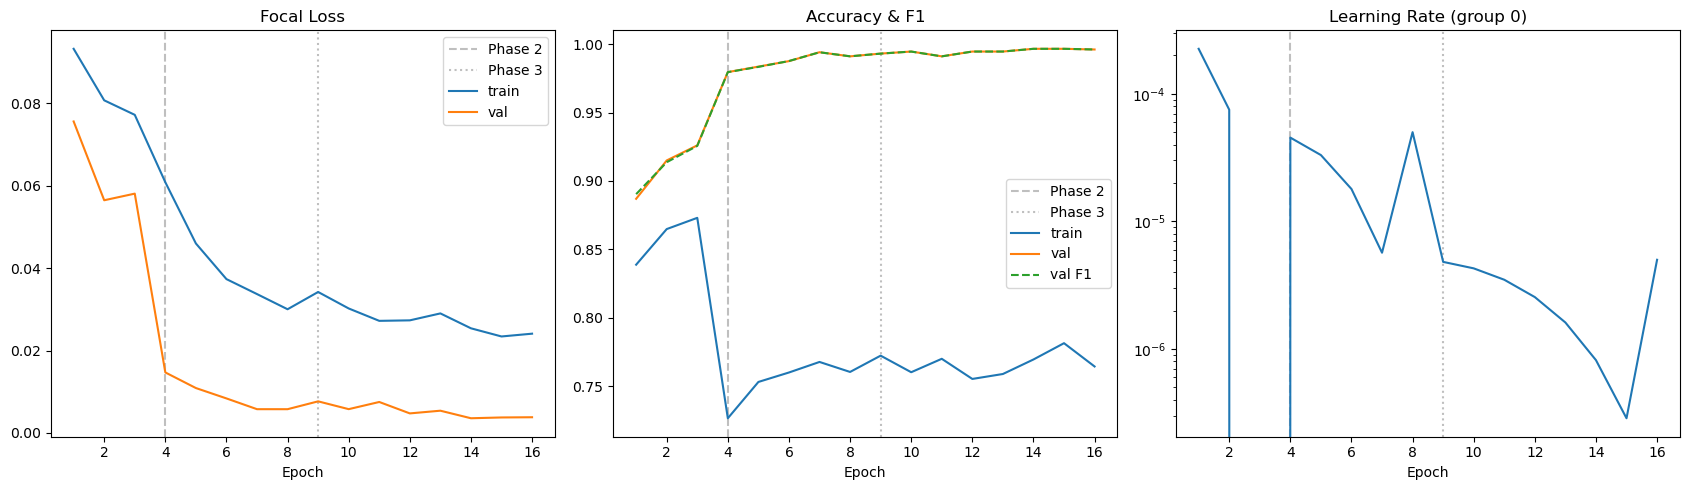

Saved tier2_training_history.png


In [13]:
epochs_range = range(1, len(history["train_loss"]) + 1)

# Phase boundary lines
p2_start = PHASE1_EPOCHS + 1
p3_start = PHASE1_EPOCHS + PHASE2_EPOCHS + 1

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for ax in axes:
    ax.axvline(p2_start, color="grey", linestyle="--", alpha=0.5, label="Phase 2")
    ax.axvline(p3_start, color="grey", linestyle=":",  alpha=0.5, label="Phase 3")

axes[0].plot(epochs_range, history["train_loss"], label="train")
axes[0].plot(epochs_range, history["val_loss"],   label="val")
axes[0].set_title("Focal Loss"); axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(epochs_range, history["train_acc"], label="train")
axes[1].plot(epochs_range, history["val_acc"],   label="val")
axes[1].plot(epochs_range, history["val_f1"],    label="val F1", linestyle="--")
axes[1].set_title("Accuracy & F1"); axes[1].set_xlabel("Epoch")
axes[1].legend()

axes[2].semilogy(epochs_range, history["lr"])
axes[2].set_title("Learning Rate (group 0)"); axes[2].set_xlabel("Epoch")

plt.tight_layout()
plt.savefig("tier2_training_history.png", dpi=150)
plt.show()
print("Saved tier2_training_history.png")

## 12. Temperature scaling calibration

Neural networks are often overconfident. Temperature scaling divides logits by a
single scalar *T* (fit on the validation set) before the softmax, bringing predicted
probabilities closer to empirical frequencies — a prerequisite for reliable
severity-level thresholds.

In [14]:
def fit_temperature(model, loader) -> torch.Tensor:
    """
    Fit a single temperature scalar on `loader` using LBFGS.
    Returns T as a 1-element tensor.
    """
    model.eval()
    logits_list, labels_list = [], []

    with torch.no_grad():
        for inputs, labels in loader:
            with autocast(enabled=USE_AMP):
                logits_list.append(model(inputs.to(device)).cpu().float())
            labels_list.append(labels)

    logits = torch.cat(logits_list).to(device)
    labels = torch.cat(labels_list).to(device)

    T    = nn.Parameter(torch.ones(1, device=device))
    nll  = nn.CrossEntropyLoss()
    opt  = torch.optim.LBFGS([T], lr=0.02, max_iter=100)

    def closure():
        opt.zero_grad()
        loss = nll(logits / T.clamp_min(1e-4), labels)
        loss.backward()
        return loss

    opt.step(closure)
    return T.detach().clamp_min(1e-4)


temperature = fit_temperature(model, val_loader)
print(f"Calibrated temperature T = {temperature.item():.4f}")
if temperature.item() > 1.0:
    print("  → Model was overconfident; probabilities have been softened.")
elif temperature.item() < 1.0:
    print("  → Model was underconfident; probabilities have been sharpened.")
else:
    print("  → Model was already well-calibrated.")

/tmp/ipykernel_24418/117928249.py:11: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USE_AMP):


Calibrated temperature T = 0.4507
  → Model was underconfident; probabilities have been sharpened.


## 13. Optimal decision threshold selection

/tmp/ipykernel_24418/2758794124.py:61: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USE_AMP):


Val PR-AUC       : 0.9999
Best F1 threshold: 0.2689


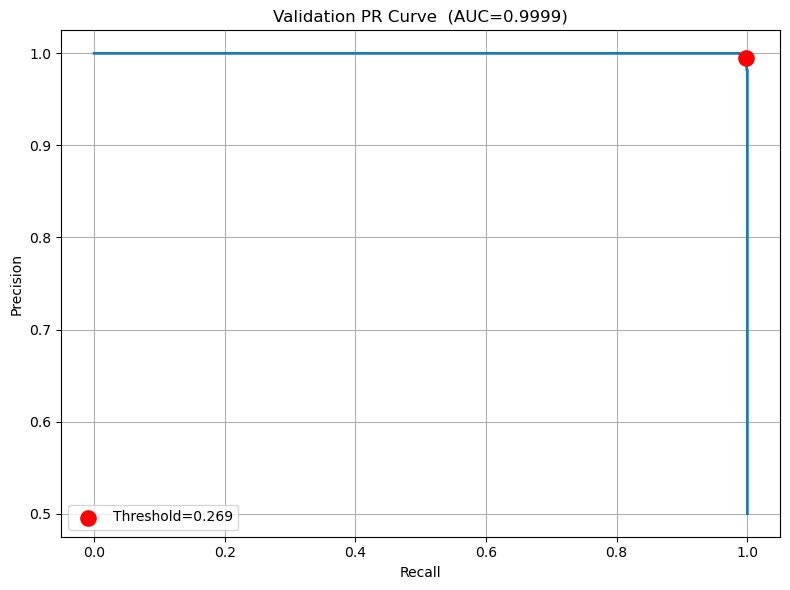

In [21]:
_, _, val_labels, _, val_logits = evaluate(model, val_loader)
val_cal_probs = (
    torch.softmax(torch.tensor(val_logits, device=device) / temperature, dim=1)
    [:, DAMAGE_IDX].cpu().numpy()
)

precision_arr, recall_arr, thresh_arr = precision_recall_curve(val_labels, val_cal_probs, pos_label=0)
pr_auc_val = auc(recall_arr, precision_arr)

# Maximise F1 on validation
f1_arr    = 2 * precision_arr[:-1] * recall_arr[:-1] / (
    precision_arr[:-1] + recall_arr[:-1] + 1e-8
)
best_idx  = int(np.argmax(f1_arr))
THRESHOLD = float(thresh_arr[best_idx])

print(f"Val PR-AUC       : {pr_auc_val:.4f}")
print(f"Best F1 threshold: {THRESHOLD:.4f}")

plt.figure(figsize=(8, 6))
plt.plot(recall_arr, precision_arr, lw=2)
plt.scatter(
    recall_arr[best_idx], precision_arr[best_idx],
    s=120, zorder=5, color="red", label=f"Threshold={THRESHOLD:.3f}",
)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Validation PR Curve  (AUC={pr_auc_val:.4f})")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("tier2_val_pr_curve.png", dpi=150)
plt.show()

## 14. Test-Time Augmentation (TTA)

TTA passes each test image through `TTA_AUGMENTATIONS` random augmented views and
averages the calibrated probability estimates, reducing prediction variance and
improving reliability on edge cases.

In [22]:
@torch.no_grad()
def predict_with_tta(
    model,
    base_loader: DataLoader,
    tta_loader: DataLoader,
    temperature: torch.Tensor,
    n_aug: int = TTA_AUGMENTATIONS,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Combine one standard (centre-crop) pass with n_aug augmented passes.

    Returns calibrated (labels, averaged_probs).
    """
    model.eval()

    def collect_logits(loader):
        logits_list, labels_list = [], []
        for imgs, lbls in loader:
            with autocast(enabled=USE_AMP):
                logits_list.append(model(imgs.to(device)).cpu().float())
            labels_list.append(lbls)
        return torch.cat(logits_list), torch.cat(labels_list)

    # Standard pass
    base_logits, labels = collect_logits(base_loader)
    prob_sum = torch.softmax(base_logits.to(device) / temperature, dim=1).cpu()

    # Augmented passes
    for aug_i in range(n_aug):
        aug_logits, _ = collect_logits(tta_loader)
        prob_sum += torch.softmax(aug_logits.to(device) / temperature, dim=1).cpu()
        print(f"  TTA pass {aug_i + 1}/{n_aug} done", end="\r")

    avg_probs = (prob_sum / (n_aug + 1))[:, DAMAGE_IDX].numpy()
    return labels.numpy(), avg_probs


print(f"Running TTA ({TTA_AUGMENTATIONS} augmented passes)...")
test_labels, test_probs_tta = predict_with_tta(
    model, test_loader, test_tta_loader, temperature,
)
print("\nTTA complete.")

Running TTA (5 augmented passes)...


/tmp/ipykernel_24418/400933180.py:19: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USE_AMP):


  TTA pass 5/5 done
TTA complete.


## 15. Test set evaluation

In [23]:
test_preds = (test_probs_tta < THRESHOLD).astype(int)

# Metrics
p_arr, r_arr, _ = precision_recall_curve(test_labels, test_probs_tta, pos_label=0)
test_pr_auc  = auc(r_arr, p_arr)
test_roc_auc = roc_auc_score(test_labels, test_probs_tta)
test_f1      = f1_score(test_labels, test_preds, zero_division=0)
test_prec    = precision_score(test_labels, test_preds, zero_division=0)
test_rec     = recall_score(test_labels, test_preds, zero_division=0)

print("─" * 50)
print(f"Test PR-AUC   : {test_pr_auc:.4f}")
print(f"Test ROC-AUC  : {test_roc_auc:.4f}")
print(f"Threshold     : {THRESHOLD:.4f}")
print(f"Precision     : {test_prec:.4f}")
print(f"Recall        : {test_rec:.4f}")
print(f"F1            : {test_f1:.4f}")
print("─" * 50)
print("\nConfusion matrix:")
cm = confusion_matrix(test_labels, test_preds)
print(cm)
print()
print(classification_report(test_labels, test_preds, target_names=CLASSES, zero_division=0))

──────────────────────────────────────────────────
Test PR-AUC   : 1.0000
Test ROC-AUC  : 0.0001
Threshold     : 0.2689
Precision     : 0.9688
Recall        : 0.9950
F1            : 0.9817
──────────────────────────────────────────────────

Confusion matrix:
[[7968   32]
 [   5  995]]

              precision    recall  f1-score   support

      damage       1.00      1.00      1.00      8000
   no_damage       0.97      0.99      0.98      1000

    accuracy                           1.00      9000
   macro avg       0.98      1.00      0.99      9000
weighted avg       1.00      1.00      1.00      9000



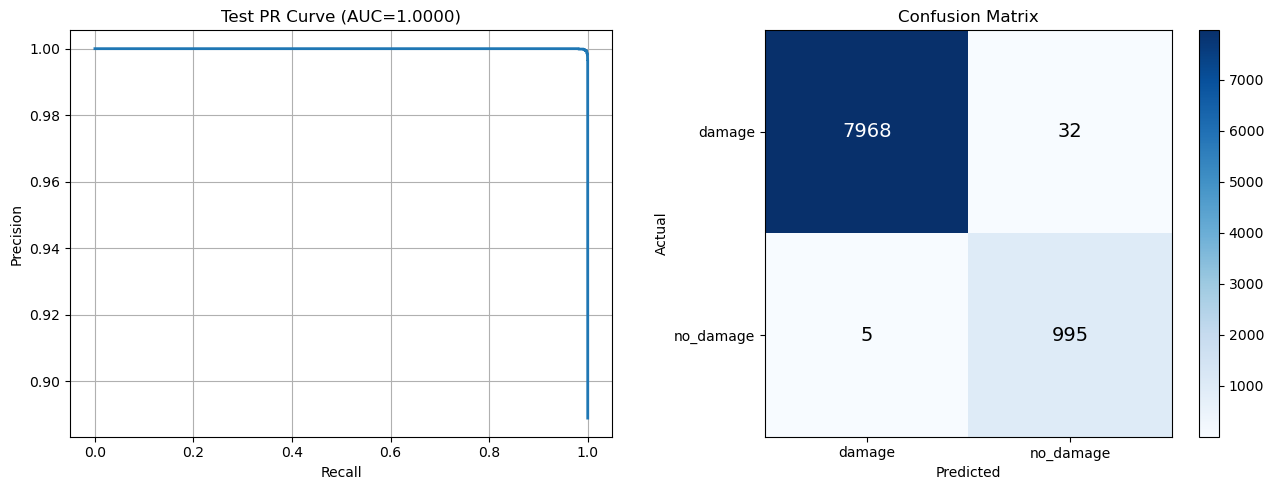

In [24]:
# Visualise PR and confusion matrix side by side
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(r_arr, p_arr, lw=2)
axes[0].set_title(f"Test PR Curve (AUC={test_pr_auc:.4f})")
axes[0].set_xlabel("Recall"); axes[0].set_ylabel("Precision")
axes[0].grid(True)

im = axes[1].imshow(cm, cmap="Blues")
axes[1].set_xticks([0, 1]); axes[1].set_xticklabels(CLASSES)
axes[1].set_yticks([0, 1]); axes[1].set_yticklabels(CLASSES)
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("Actual")
axes[1].set_title("Confusion Matrix")
for i in range(2):
    for j in range(2):
        axes[1].text(j, i, cm[i, j], ha="center", va="center",
                     color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=14)
plt.colorbar(im, ax=axes[1])

plt.tight_layout()
plt.savefig("tier2_test_evaluation.png", dpi=150)
plt.show()

## 16. Probability distribution analysis

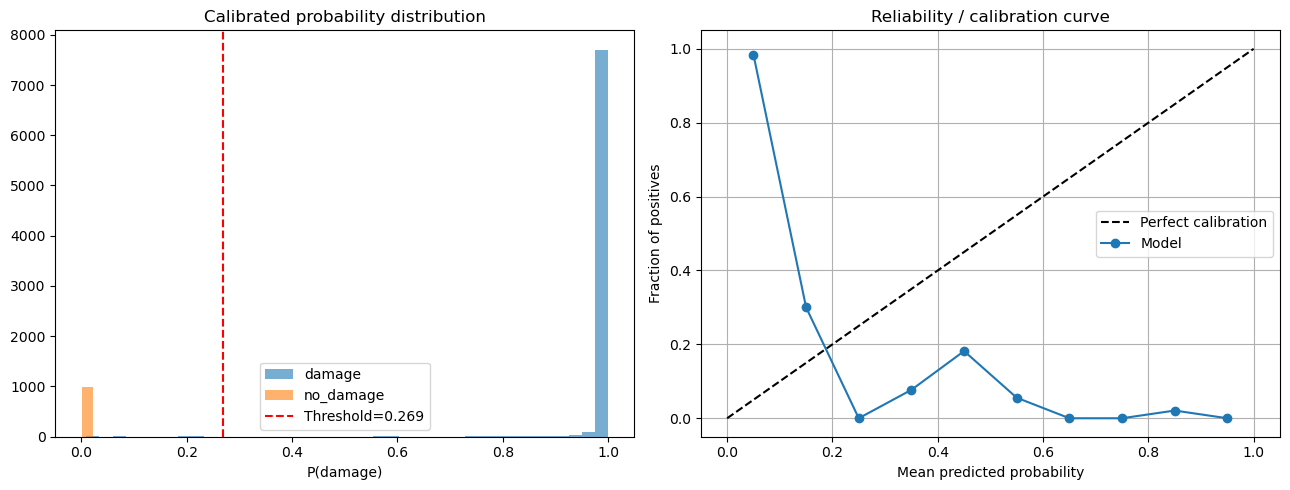

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for cls_idx, cls_name in enumerate(CLASSES):
    mask = test_labels == cls_idx
    axes[0].hist(test_probs_tta[mask], bins=40, alpha=0.6, label=cls_name)
axes[0].axvline(THRESHOLD, color="red", linestyle="--", label=f"Threshold={THRESHOLD:.3f}")
axes[0].set_title("Calibrated probability distribution")
axes[0].set_xlabel("P(damage)")
axes[0].legend()

# Reliability / calibration plot
n_bins = 10
bin_edges   = np.linspace(0, 1, n_bins + 1)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
bin_fracs   = []
for lo, hi in zip(bin_edges[:-1], bin_edges[1:]):
    mask = (test_probs_tta >= lo) & (test_probs_tta < hi)
    if mask.sum() > 0:
        bin_fracs.append(test_labels[mask].mean())
    else:
        bin_fracs.append(np.nan)

axes[1].plot([0, 1], [0, 1], "k--", label="Perfect calibration")
axes[1].plot(bin_centers, bin_fracs, "o-", label="Model")
axes[1].set_title("Reliability / calibration curve")
axes[1].set_xlabel("Mean predicted probability")
axes[1].set_ylabel("Fraction of positives")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig("tier2_calibration.png", dpi=150)
plt.show()

## 17. GradCAM — explainability heatmaps

GradCAM backpropagates gradients of the target class score w.r.t. the last
convolutional feature map to produce a spatial importance heatmap. This helps
analysts verify *which* regions drove the model's damage verdict.

AttributeError: 'numpy.ndarray' object has no attribute 'jet'

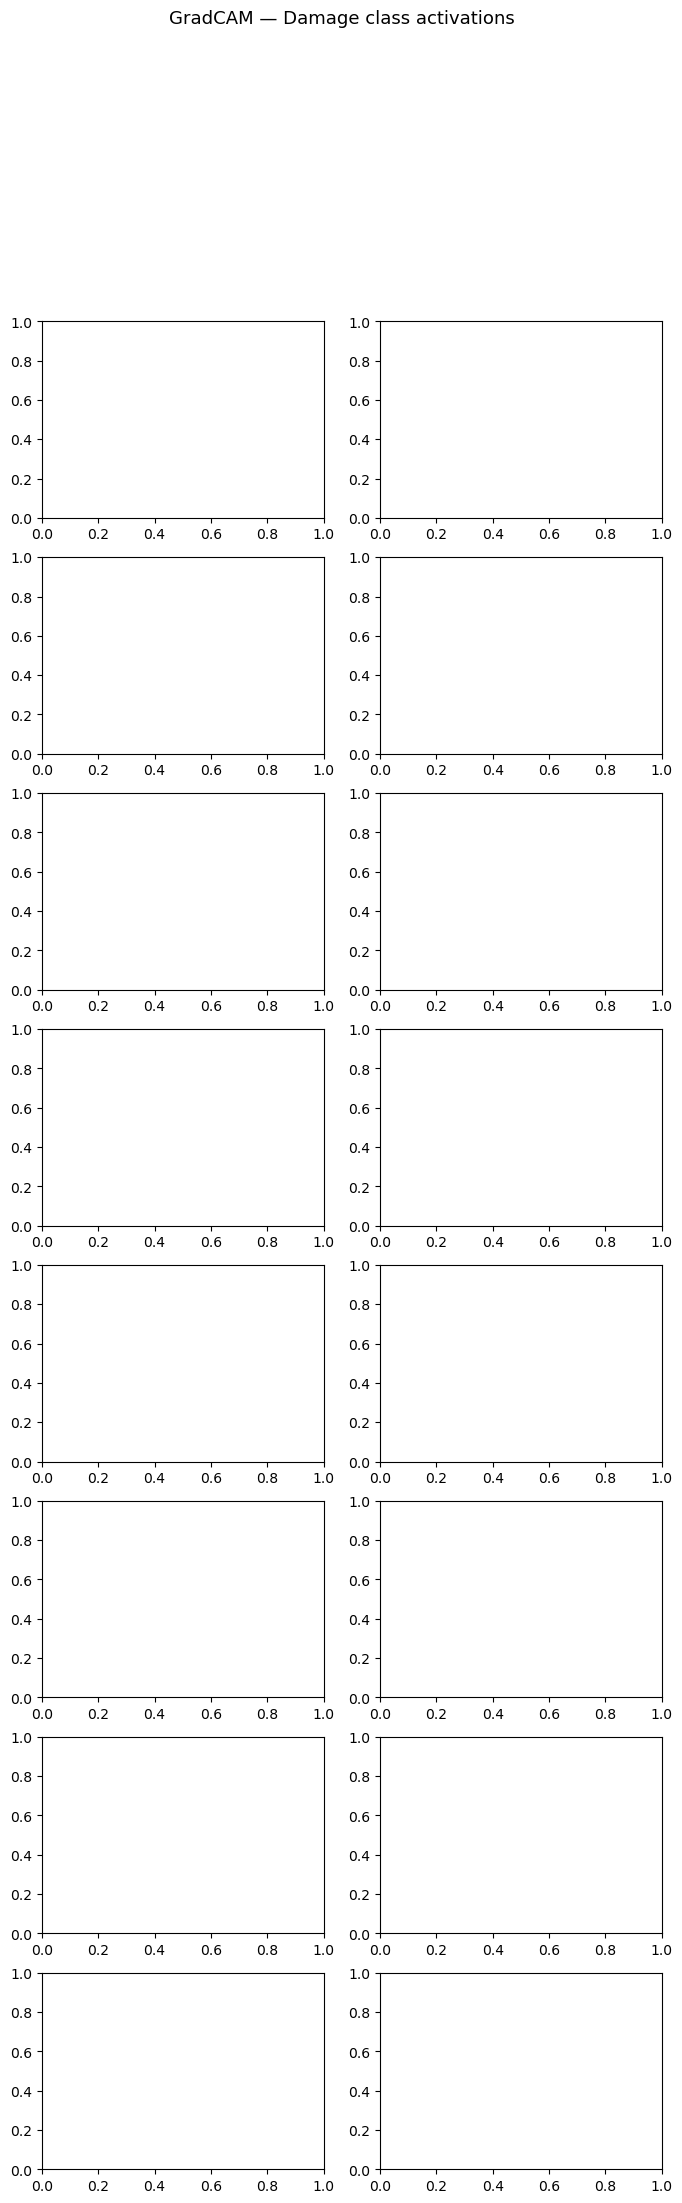

In [26]:
class GradCAM:
    """Minimal GradCAM implementation, hooks the supplied target layer."""

    def __init__(self, model: nn.Module, target_layer: nn.Module):
        self.model        = model
        self.activations  = None
        self.gradients    = None
        self._fwd_hook    = target_layer.register_forward_hook(self._save_activations)
        self._bwd_hook    = target_layer.register_full_backward_hook(self._save_gradients)

    def _save_activations(self, _, __, output):
        self.activations = output.detach()

    def _save_gradients(self, _, __, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor: torch.Tensor, class_idx: int = None) -> np.ndarray:
        self.model.zero_grad()
        output = self.model(input_tensor)
        if class_idx is None:
            class_idx = output.argmax(dim=1).item()
        output[:, class_idx].backward()

        weights = self.gradients.mean(dim=[2, 3], keepdim=True)  # global avg pool
        cam     = (weights * self.activations).sum(dim=1, keepdim=True)
        cam     = F.relu(cam)
        cam     = F.interpolate(
            cam, size=input_tensor.shape[-2:], mode="bilinear", align_corners=False
        )
        cam = cam.squeeze().cpu().numpy()
        cam_min, cam_max = cam.min(), cam.max()
        if cam_max > cam_min:
            cam = (cam - cam_min) / (cam_max - cam_min)
        return cam

    def remove_hooks(self):
        self._fwd_hook.remove()
        self._bwd_hook.remove()


def denorm(t: torch.Tensor) -> np.ndarray:
    """Denormalise an ImageNet-normalised CHW tensor to HWC uint8."""
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std  = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return ((t.cpu() * std + mean).permute(1, 2, 0).numpy().clip(0, 1) * 255).astype(np.uint8)


def overlay_heatmap(image: np.ndarray, cam: np.ndarray, alpha: float = 0.45) -> np.ndarray:
    heatmap = (cm.jet(cam)[:, :, :3] * 255).astype(np.uint8)
    return (alpha * heatmap + (1 - alpha) * image).astype(np.uint8)


# Target layer: last conv block of EfficientNet-V2-M features
target_layer = list(model.features.children())[-1]
grad_cam     = GradCAM(model, target_layer)

model.eval()
n_show  = 8
indices = random.sample(range(len(test_dataset)), n_show)

fig, axes = plt.subplots(n_show, 2, figsize=(8, n_show * 3))
fig.suptitle("GradCAM — Damage class activations", fontsize=13, y=1.01)

for row, idx in enumerate(indices):
    img_tensor, true_label = test_dataset[idx]
    inp = img_tensor.unsqueeze(0).to(device)

    cam_map  = grad_cam.generate(inp, class_idx=DAMAGE_IDX)
    raw_img  = denorm(img_tensor)
    overlaid = overlay_heatmap(raw_img, cam_map)

    pred_prob  = float(torch.softmax(model(inp), dim=1)[0, DAMAGE_IDX].item())
    pred_label = CLASSES[0 if pred_prob >= THRESHOLD else 1]
    true_name  = CLASSES[true_label]

    colour = "green" if pred_label == true_name else "red"

    axes[row, 0].imshow(raw_img)
    axes[row, 0].set_title(f"True: {true_name}", fontsize=8)
    axes[row, 0].axis("off")

    axes[row, 1].imshow(overlaid)
    axes[row, 1].set_title(f"Pred: {pred_label}  p={pred_prob:.3f}",
                           fontsize=8, color=colour)
    axes[row, 1].axis("off")

plt.tight_layout()
plt.savefig("tier2_gradcam.png", dpi=150, bbox_inches="tight")
plt.show()
grad_cam.remove_hooks()
print("GradCAM visualisations saved.")

## 18. Severity-aware disaster intelligence map

Each calibrated damage probability is mapped to an operational severity tier and
recommended response action, enabling downstream triage without manual review of
every flagged image.

In [ ]:
SEVERITY_TIERS = [
    # (min_prob, tier_name, response_action)
    (0.95, "critical",  "IMMEDIATE — dispatch emergency response team"),
    (0.80, "severe",    "URGENT — escalate to field validation within 2 h"),
    (0.65, "moderate",  "ELEVATED — flag for analyst triage within 24 h"),
    (0.50, "marginal",  "MONITOR — queue for secondary automated pass"),
    (0.00, "none",      "No escalation required"),
]


def classify_severity(prob: float, predicted_damage: bool) -> tuple[str, str]:
    """Return (severity, response_action) from calibrated damage probability."""
    if not predicted_damage:
        return "none", "No escalation required"
    for min_p, tier, action in SEVERITY_TIERS:
        if prob >= min_p:
            return tier, action
    return "none", "No escalation required"


records = []
for (img_path, _), true_lbl, prob in zip(
    test_dataset.samples, test_labels, test_probs_tta
):
    pred_damage   = bool(prob >= THRESHOLD)
    severity, action = classify_severity(float(prob), pred_damage)
    records.append({
        "image_path":        img_path,
        "actual_label":      CLASSES[int(true_lbl)],
        "predicted_label": CLASSES[0 if pred_damage else 1],
        "correct": CLASSES[int(true_lbl)] == CLASSES[0 if pred_damage else 1],
        "damage_probability": round(float(prob), 6),
        "severity":          severity,
        "response_action":   action,
    })

# Summary
from collections import Counter
tier_counts = Counter(r["severity"] for r in records)
print("Severity tier distribution (test set):")
for tier, action in SEVERITY_TIERS:
    name = action.split(" ")[0].rstrip("—").strip()
    tier_name = [t for _, t, _ in SEVERITY_TIERS if _ == action]

for _, tier, action in SEVERITY_TIERS:
    print(f"  {tier:10s}: {tier_counts.get(tier, 0):4d} images  |  {action}")

# Save JSON
intel_path = Path("tier2_disaster_intelligence_map.json")
intel_path.write_text(json.dumps(records, indent=2))
print(f"\nSaved intelligence map → {intel_path}  ({len(records)} records)")

In [ ]:
# Severity distribution bar chart
tier_order = [t for _, t, _ in SEVERITY_TIERS]
counts     = [tier_counts.get(t, 0) for t in tier_order]
colours    = ["#d32f2f", "#f57c00", "#fbc02d", "#388e3c", "#1565c0"]

plt.figure(figsize=(9, 5))
bars = plt.bar(tier_order, counts, color=colours, edgecolor="white", linewidth=0.8)
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
             str(count), ha="center", va="bottom", fontsize=10)
plt.title("Severity tier distribution — Test set")
plt.xlabel("Severity tier")
plt.ylabel("Image count")
plt.tight_layout()
plt.savefig("tier2_severity_distribution.png", dpi=150)
plt.show()

## 19. Save full model checkpoint

In [ ]:
checkpoint = {
    # Model
    "model_state_dict":   model.state_dict(),
    "architecture":       "efficientnet_v2_m",
    "num_classes":        len(CLASSES),
    "class_names":        CLASSES,
    "damage_class_idx":   DAMAGE_IDX,
    # Inference config
    "image_size":         IMAGE_SIZE,
    "imagenet_mean":      IMAGENET_MEAN,
    "imagenet_std":       IMAGENET_STD,
    "temperature":        float(temperature.item()),
    "threshold":          THRESHOLD,
    "tta_augmentations":  TTA_AUGMENTATIONS,
    # Training metadata
    "phase1_epochs":      PHASE1_EPOCHS,
    "phase2_epochs":      PHASE2_EPOCHS,
    "phase3_epochs":      PHASE3_EPOCHS,
    "focal_gamma":        FOCAL_GAMMA,
    "label_smoothing":    LABEL_SMOOTHING,
    "mixup_alpha":        MIXUP_ALPHA,
    # Performance
    "best_val_f1":        best_val_f1,
    "test_f1":            test_f1,
    "test_pr_auc":        test_pr_auc,
    "test_roc_auc":       test_roc_auc,
    "history":            history,
    # Severity config
    "severity_tiers":     [(p, t, a) for p, t, a in SEVERITY_TIERS],
}

ckpt_path = Path("trained_model_tier2.pth")
torch.save(checkpoint, ckpt_path)
print(f"Full checkpoint saved → {ckpt_path}")
print(f"  Best val F1  : {best_val_f1:.4f}")
print(f"  Test F1      : {test_f1:.4f}")
print(f"  Test PR-AUC  : {test_pr_auc:.4f}")
print(f"  Test ROC-AUC : {test_roc_auc:.4f}")

## 20. Inference helper — loading and using the saved model

The cell below shows how to reload the checkpoint and run inference on a single
image file, including calibration and TTA.

In [ ]:
def load_tier2_model(checkpoint_path: str = "trained_model_tier2.pth"):
    """Reload the Tier 2 model from a saved checkpoint."""
    ckpt = torch.load(checkpoint_path, map_location=device)
    mdl  = build_model(num_classes=ckpt["num_classes"]).to(device)
    mdl.load_state_dict(ckpt["model_state_dict"])
    mdl.eval()
    T   = torch.tensor(ckpt["temperature"], device=device)
    thr = ckpt["threshold"]
    return mdl, T, thr, ckpt


def predict_single_image(
    image_path: str,
    model,
    temperature: torch.Tensor,
    threshold: float,
    class_names: list,
    damage_idx: int = 1,
    tta_passes: int = TTA_AUGMENTATIONS,
) -> dict:
    """
    Full inference pipeline for a single image path.

    Returns a dict with predicted label, calibrated probability, severity, and action.
    """
    image = Image.open(image_path).convert("RGB")

    # Standard pass
    inp      = eval_transform(image).unsqueeze(0).to(device)
    with torch.no_grad():
        logits = model(inp)
    prob_sum = torch.softmax(logits / temperature, dim=1).cpu()

    # TTA passes
    for _ in range(tta_passes):
        aug_inp = tta_transform(image).unsqueeze(0).to(device)
        with torch.no_grad():
            aug_logits = model(aug_inp)
        prob_sum += torch.softmax(aug_logits / temperature, dim=1).cpu()

    avg_probs    = (prob_sum / (tta_passes + 1)).squeeze()
    damage_prob  = float(avg_probs[damage_idx].item())
    pred_damage  = damage_prob >= threshold
    severity, action = classify_severity(damage_prob, pred_damage)

    return {
        "predicted_label":    class_names[int(pred_damage)],
        "damage_probability": round(damage_prob, 6),
        "severity":           severity,
        "response_action":    action,
        "all_probs":          {c: round(float(p), 6) for c, p in zip(class_names, avg_probs.tolist())},
    }


# ── Demonstration ─────────────────────────────────────────────────────────────
# Uncomment and edit the path to test on any image:
#
# result = predict_single_image(
#     image_path="data/test_another/damage/some_image.jpeg",
#     model=model,
#     temperature=temperature,
#     threshold=THRESHOLD,
#     class_names=CLASSES,
# )
# print(json.dumps(result, indent=2))

print("Inference helper functions defined.")
print("\nAll outputs saved:")
for f in [
    "trained_model_tier2.pth",
    "tier2_disaster_intelligence_map.json",
    "tier2_training_history.png",
    "tier2_val_pr_curve.png",
    "tier2_test_evaluation.png",
    "tier2_calibration.png",
    "tier2_gradcam.png",
    "tier2_severity_distribution.png",
]:
    print(f"  {f}")

In [ ]:
# Grab one batch from the val loader
model.eval()
images, labels = next(iter(val_loader))
images = images.to(device)

with torch.no_grad():
    logits = model(images)
    probs = torch.softmax(logits, dim=1)

print("Classes:", CLASSES)
print("DAMAGE_IDX:", DAMAGE_IDX)
print()
print("Sample labels:        ", labels[:8].tolist())
print("Sample logits:        ", logits[:8].round().tolist())
print("Sample probs (full):  ", probs[:8].round(decimals=2).tolist())
print("Sample damage probs:  ", probs[:8, DAMAGE_IDX].round(decimals=2).tolist())
print("Sample predictions:   ", probs[:8].argmax(dim=1).tolist())

In [ ]:
print("Val folder contents:")
for cls_dir in sorted(VAL_DIR.iterdir()):
    if cls_dir.is_dir():
        count = len(list(cls_dir.glob("*.*")))
        print(f"  {cls_dir.name}: {count} images")

print("\nVal dataset class breakdown:")
val_labels_all = [label for _, label in val_dataset.samples]
import collections
print(collections.Counter(val_labels_all))

In [ ]:
model.eval()
all_labels, all_preds, all_damage_probs = [], [], []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        logits = model(images)
        probs = torch.softmax(logits, dim=1)
        
        all_labels.extend(labels.tolist())
        all_preds.extend(probs.argmax(dim=1).tolist())
        all_damage_probs.extend(probs[:, DAMAGE_IDX].tolist())

import numpy as np
all_labels = np.array(all_labels)
all_preds = np.array(all_preds)
all_damage_probs = np.array(all_damage_probs)

print("Label distribution:     ", collections.Counter(all_labels.tolist()))
print("Prediction distribution:", collections.Counter(all_preds.tolist()))
print()
print("Damage prob range:  ", all_damage_probs.min().round(3), "→", all_damage_probs.max().round(3))
print("Damage prob mean:   ", all_damage_probs.mean().round(3))
print()
print("Accuracy:", (all_preds == all_labels).mean().round(3))
from sklearn.metrics import f1_score, confusion_matrix
print("F1:      ", f1_score(all_labels, all_preds, zero_division=0).round(3))
print("Confusion matrix:")
print(confusion_matrix(all_labels, all_preds))